# Clasificación de Tumores Cerebrales

**Dataset:** [Brain Tumor Dataset — Kaggle (miadul)](https://www.kaggle.com/datasets/miadul/brain-tumor-dataset)  
**Objetivo:** Predecir si un tumor es **Benigno** o **Maligno** a partir de variables clínicas del paciente.  
  
Diego Dueñas Martín  
Exp 751426  
9/4/2026  
---

### Pipeline general

```
1. Carga del dataset
2. Exploración inicial (EDA)
3. Limpieza y codificación
4. Preprocesamiento numérico
5. División train/test
6. Entrenamiento del modelo (Random Forest)
7. Evaluación y métricas
8. Análisis adicionales
```

---
## 1. Carga del dataset

Descargamos el dataset directamente desde Kaggle usando `kagglehub`.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Descarga del dataset
path = kagglehub.dataset_download("miadul/brain-tumor-dataset")
print("Archivos disponibles:", os.listdir(path))

C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Archivos disponibles: ['brain_tumor_dataset.csv']


In [2]:
csv_path = os.path.join(path, 'brain_tumor_dataset.csv')
df = pd.read_csv(csv_path)

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 20000 filas × 19 columnas


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


---
## 2. Exploración inicial (EDA)

Antes de tocar cualquier dato, conviene entender qué tenemos: tipos de columnas, distribuciones, valores faltantes y posibles anomalías.

In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Valores nulos ===")
print(df.isnull().sum())
print("\n=== Estadísticas descriptivas ===")
df.describe(include='all')

=== Tipos de datos ===
Patient_ID               int64
Age                      int64
Gender                  object
Tumor_Type              object
Tumor_Size             float64
Location                object
Histology               object
Stage                   object
Symptom_1               object
Symptom_2               object
Symptom_3               object
Radiation_Treatment     object
Surgery_Performed       object
Chemotherapy            object
Survival_Rate          float64
Tumor_Growth_Rate      float64
Family_History          object
MRI_Result              object
Follow_Up_Required      object
dtype: object

=== Valores nulos ===
Patient_ID             0
Age                    0
Gender                 0
Tumor_Type             0
Tumor_Size             0
Location               0
Histology              0
Stage                  0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
S

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
count,20000.000000,20000.000000,20000,20000,20000.000000,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000.000000,20000.000000,20000,20000,20000
unique,NaN,NaN,2,2,NaN,4,4,4,4,4,4,2,2,2,NaN,NaN,2,2,2
top,NaN,NaN,Female,Malignant,NaN,Temporal,Glioblastoma,II,Headache,Seizures,Seizures,Yes,Yes,Yes,NaN,NaN,No,Positive,Yes
freq,NaN,NaN,10016,10030,NaN,5118,5068,5093,5045,5054,5027,10021,10060,10097,NaN,NaN,10002,10029,10101
mean,10000.500000,49.433700,NaN,NaN,5.236552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.131699,1.547701,NaN,NaN,NaN
std,5773.647028,17.389296,NaN,NaN,2.754359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.270834,0.835995,NaN,NaN,NaN
min,1.000000,20.000000,NaN,NaN,0.500410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.002386,0.100017,NaN,NaN,NaN
25%,5000.750000,34.000000,NaN,NaN,2.836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.224439,0.830433,NaN,NaN,NaN
50%,10000.500000,49.000000,NaN,NaN,5.200675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.305066,1.541821,NaN,NaN,NaN
75%,15000.250000,65.000000,NaN,NaN,7.624299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.043395,2.262484,NaN,NaN,NaN


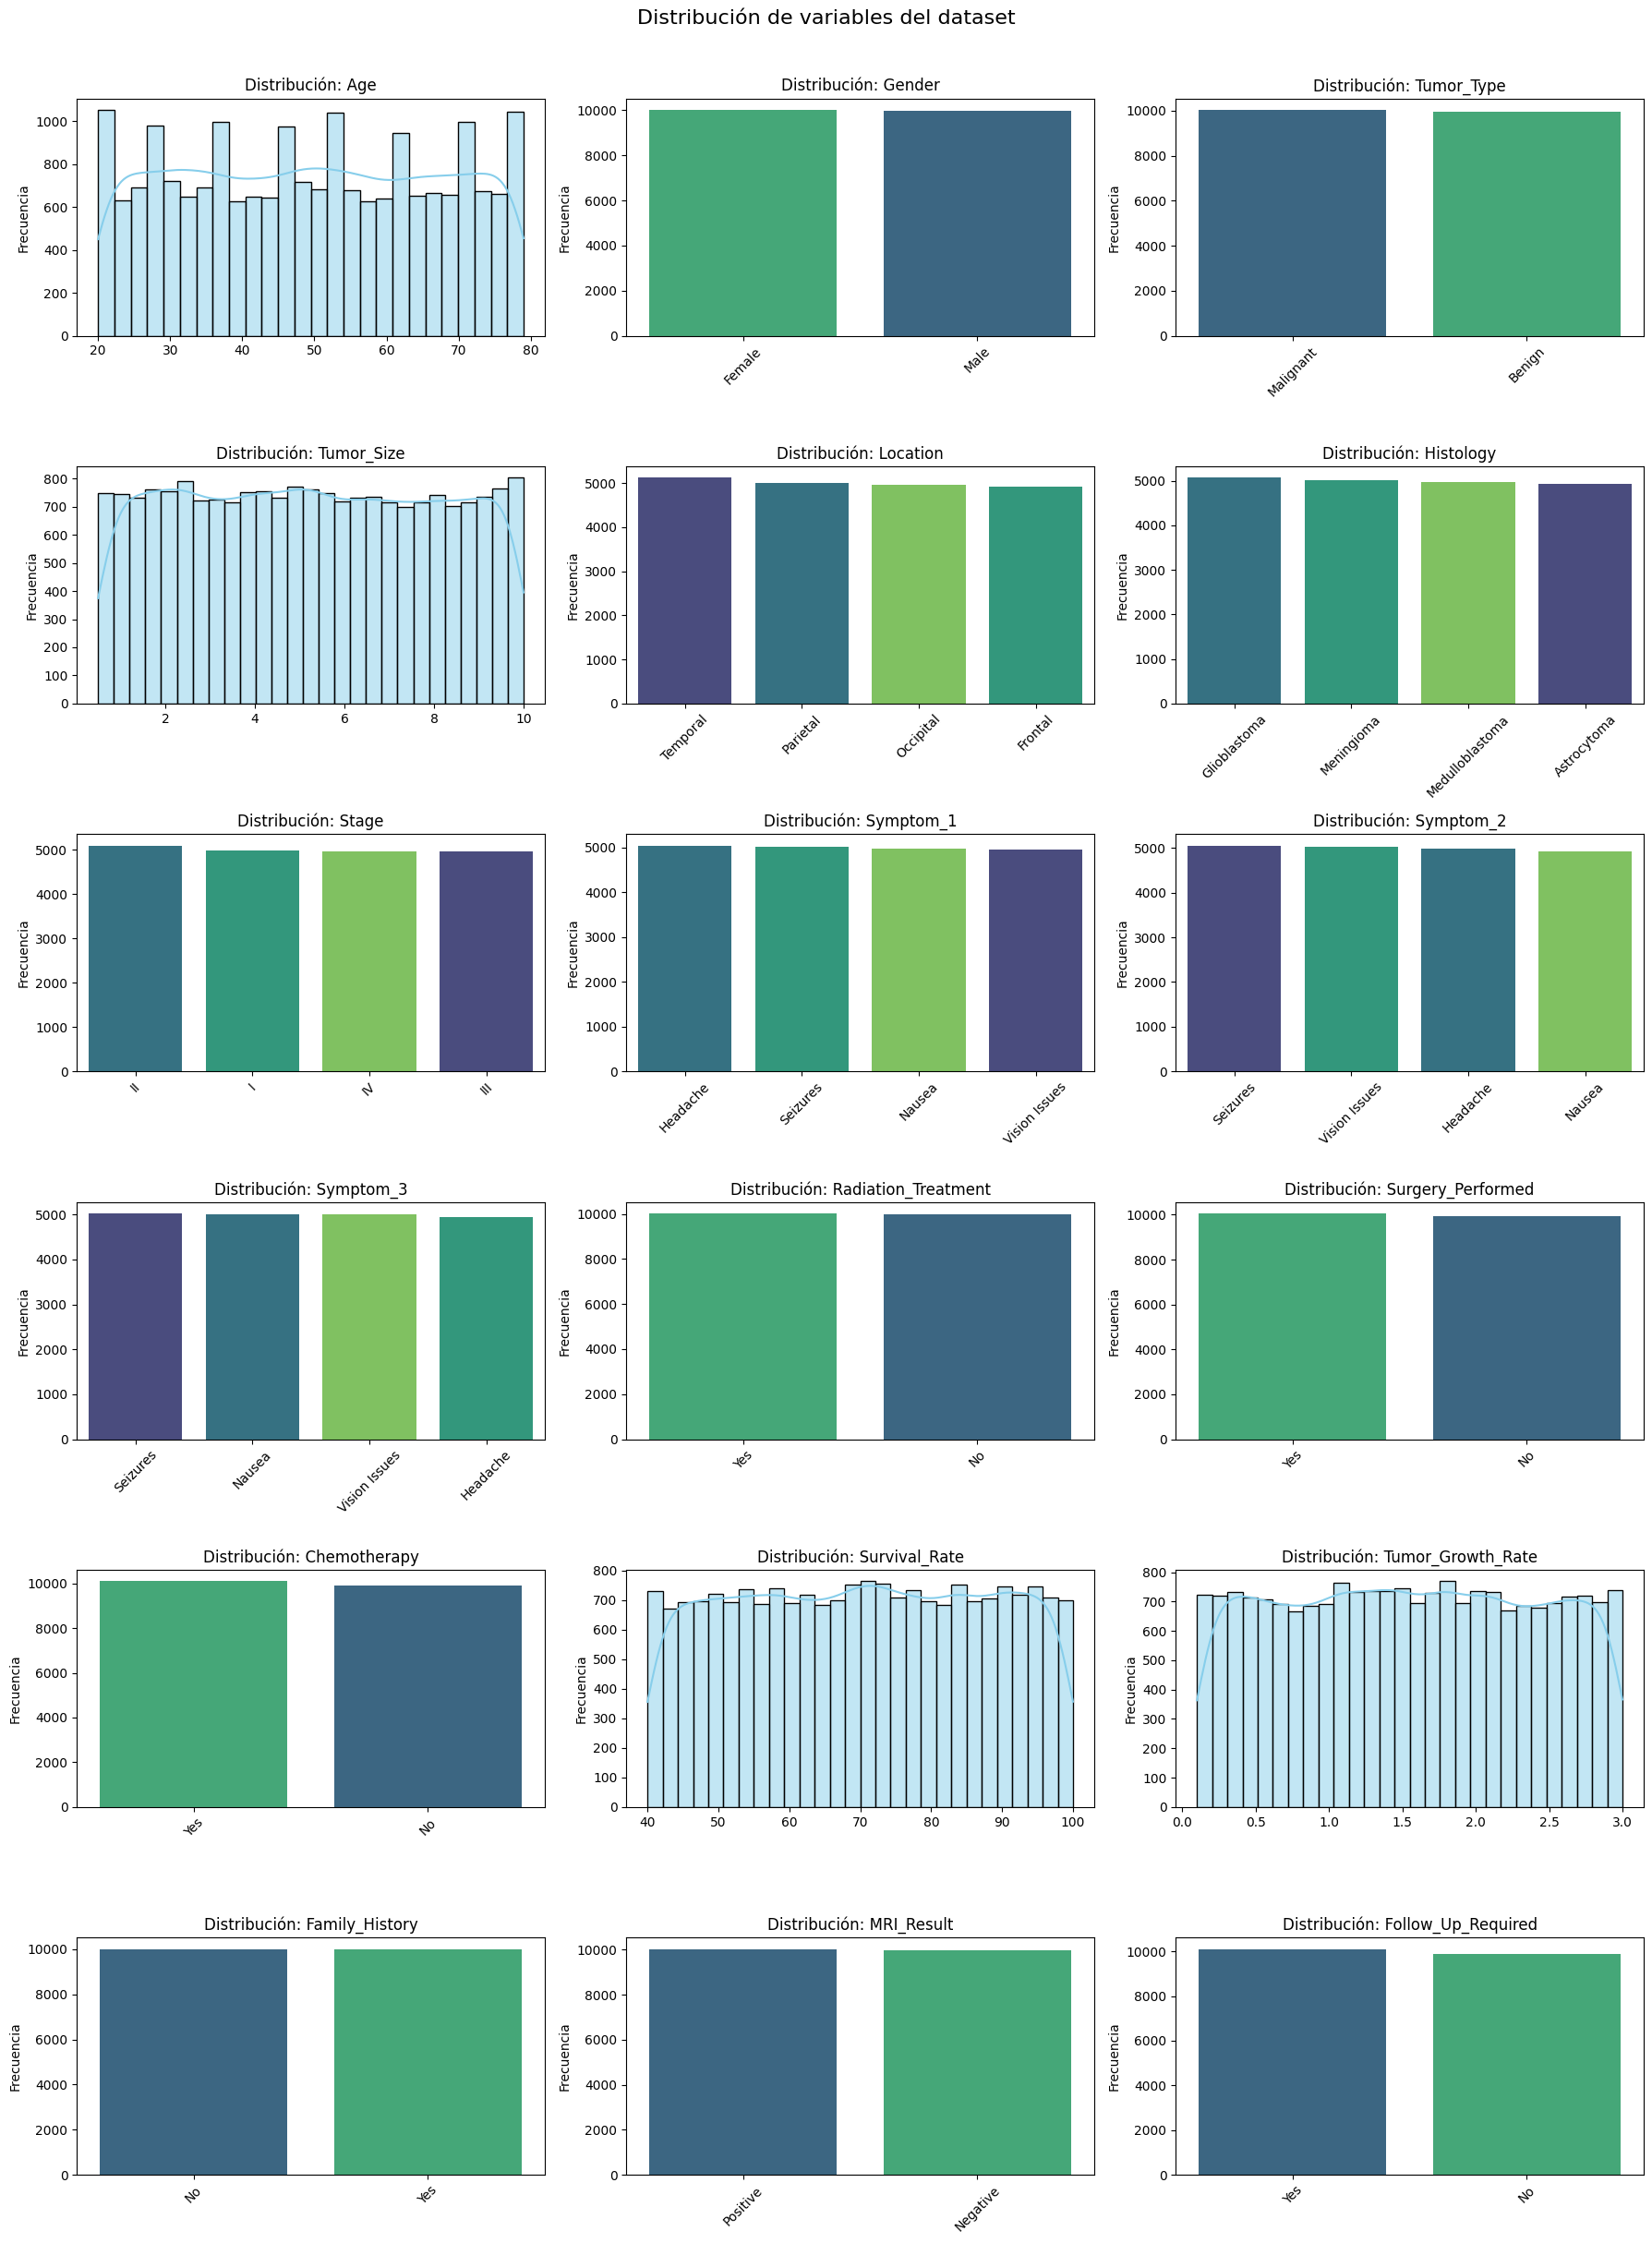

In [4]:
# Distribución de cada variable (numéricas con histograma, categóricas con conteo)
cols = [c for c in df.columns if c != 'Patient_ID']
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    if df[col].dtype in ['float64', 'int64']:
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    else:
        order = df[col].value_counts().index[:10]
        sns.countplot(data=df, x=col, ax=axes[i], hue=col,
                      palette='viridis', order=order, legend=False)
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de variables del dataset', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Limpieza y codificación

El dataset tiene variables categóricas que el modelo no puede leer directamente. Las convertimos a valores numéricos:

| Variable | Tipo | Transformación |
|---|---|---|
| `Tumor_Type` | Binaria | `Benign → 0`, `Malignant → 1` |
| `Gender` | Binaria | `Male → 0`, `Female → 1` |
| `Radiation_Treatment`, `Surgery_Performed`, etc. | Binaria (Sí/No) | `Yes → 1`, `No → 0` |
| `MRI_Result` | Binaria | `Positive/Yes → 1`, `Negative/No → 0` |
| `Stage` | Ordinal | `I → 0, II → 1, III → 2, IV → 3` |

In [5]:
# Revisar valores únicos antes de mapear
print("MRI_Result:", df['MRI_Result'].unique())
print("Tumor_Type:", df['Tumor_Type'].unique())
print("Stage:",      df['Stage'].unique())

MRI_Result: ['Positive' 'Negative']
Tumor_Type: ['Malignant' 'Benign']
Stage: ['III' 'II' 'I' 'IV']


In [6]:
from sklearn.preprocessing import OrdinalEncoder

# --- Variables binarias ---
mapping_binary = {'Yes': 1, 'No': 0}
mapping_gender  = {'Male': 0, 'Female': 1}
mapping_tumor   = {'Benign': 0, 'Malignant': 1}

df['Tumor_Type'] = df['Tumor_Type'].str.strip().map(mapping_tumor)
df['Gender']     = df['Gender'].str.strip().map(mapping_gender)

binary_cols = ['Radiation_Treatment', 'Surgery_Performed',
               'Chemotherapy', 'Family_History', 'Follow_Up_Required']
for col in binary_cols:
    df[col] = df[col].str.strip().map(mapping_binary)

# MRI_Result puede traer distintos formatos según la versión del dataset
df['MRI_Result'] = df['MRI_Result'].str.strip().map(
    {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0}
)

# --- Variable ordinal: Stage (I < II < III < IV) ---
stages_order = ['I', 'II', 'III', 'IV']
encoder = OrdinalEncoder(categories=[stages_order])
df['Stage'] = encoder.fit_transform(df[['Stage']].applymap(lambda x: str(x).strip()))

print("Nulos tras codificación:")
print(df[['Tumor_Type', 'Gender', 'MRI_Result', 'Stage'] + binary_cols].isnull().sum())

df[['Tumor_Type', 'Gender', 'MRI_Result', 'Stage'] + binary_cols].head()

Nulos tras codificación:
Tumor_Type             0
Gender                 0
MRI_Result             0
Stage                  0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
Family_History         0
Follow_Up_Required     0
dtype: int64


C:\Users\didum\AppData\Local\Temp\ipykernel_22224\3496899200.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df['Stage'] = encoder.fit_transform(df[['Stage']].applymap(lambda x: str(x).strip()))


,Tumor_Type,Gender,MRI_Result,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,Family_History,Follow_Up_Required
0,1,0,1,2.0,0,0,0,0,1
1,0,0,1,1.0,1,1,1,1,1
2,0,0,0,0.0,0,0,0,0,0
3,1,0,0,3.0,1,0,1,1,0
4,0,1,1,0.0,0,0,1,0,1


---
## 4. Preprocesamiento numérico

Las columnas numéricas continuas (`Age`, `Tumor_Size`, `Survival_Rate`, `Tumor_Growth_Rate`) están en escalas muy distintas. Aplicamos **MinMaxScaler** para llevarlas al rango [0, 1] y evitar que el modelo le dé más peso a variables con valores grandes.

In [7]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Rango tras escalar:")
print(df[numeric_cols].describe().loc[['min', 'max']])

df[numeric_cols + ['Stage']].head()

Rango tras escalar:
     Age  Tumor_Size  Survival_Rate  Tumor_Growth_Rate
min  0.0         0.0            0.0                0.0
max  1.0         1.0            1.0                1.0


,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate,Stage
0,0.898305,0.513233,0.188517,0.004090,2.0
1,0.101695,0.457594,0.106189,0.712361,1.0
2,0.186441,0.535633,0.117839,0.615284,0.0
3,0.152542,0.098557,0.197535,0.408069,3.0
4,0.576271,0.201821,0.245127,0.679167,0.0


---
## 5. División train / test

Dividimos el dataset en **80% entrenamiento** y **20% prueba**. Usamos `stratify=y` para que la proporción de tumores benignos/malignos sea la misma en ambos subconjuntos.

In [8]:
from sklearn.model_selection import train_test_split

features = ['Age', 'Gender', 'Tumor_Size', 'Radiation_Treatment',
            'Surgery_Performed', 'Chemotherapy', 'Survival_Rate',
            'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
            'Follow_Up_Required', 'Stage']

X = df[features]
y = df['Tumor_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print("\nBalance de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).rename({0: 'Benigno', 1: 'Maligno'}))

Train: 16000 muestras | Test: 4000 muestras

Balance de clases en entrenamiento:
Tumor_Type
Maligno    0.5015
Benigno    0.4985
Name: proportion, dtype: float64


---
## 6. Entrenamiento del modelo — Support Vector Machine

Cambiamos a **SVM (Support Vector Machine)**. La idea central: encontrar el hiperplano que separa las clases con el mayor margen posible.

El parámetro **C** controla el balance entre margen y errores de clasificación:

| C pequeño | C grande |
|---|---|
| Margen amplio, más errores permitidos | Margen estrecho, intenta no cometer errores |
| Tiende a **underfitting** | Tiende a **overfitting** |

Usamos `GridSearchCV` para probar varios valores de C y quedarnos con el que mejor generaliza, evaluado con F1 en validación cruzada interna de 5 folds.

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Rango de valores de C a explorar (escala logarítmica)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_C   = grid_search.best_params_['C']
best_f1  = grid_search.best_score_
model    = grid_search.best_estimator_

print(f'Mejor C encontrado : {best_C}')
print(f'F1 en validacion   : {best_f1:.4f}')

# Evaluacion final sobre el test set
y_pred = model.predict(X_test)
print(f'\nF1 en test         : {f1_score(y_test, y_pred):.4f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejor C encontrado : 0.001
F1 en validacion   : 0.6680

F1 en test         : 0.6680

Reporte de clasificacion:
              precision    recall  f1-score   support

     Benigno       0.00      0.00      0.00      1994
     Maligno       0.50      1.00      0.67      2006

    accuracy                           0.50      4000
   macro avg       0.25      0.50      0.33      4000
weighted avg       0.25      0.50      0.34      4000



C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\didum\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

---
## 7. Evaluación visual

### Matriz de confusión

Muestra cuántos casos el modelo clasificó correctamente y en qué se equivocó:
- **True Positive (TP):** Predijo Maligno y era Maligno   
- **True Negative (TN):** Predijo Benigno y era Benigno   
- **False Positive (FP):** Predijo Maligno pero era Benigno 
- **False Negative (FN):** Predijo Benigno pero era Maligno 

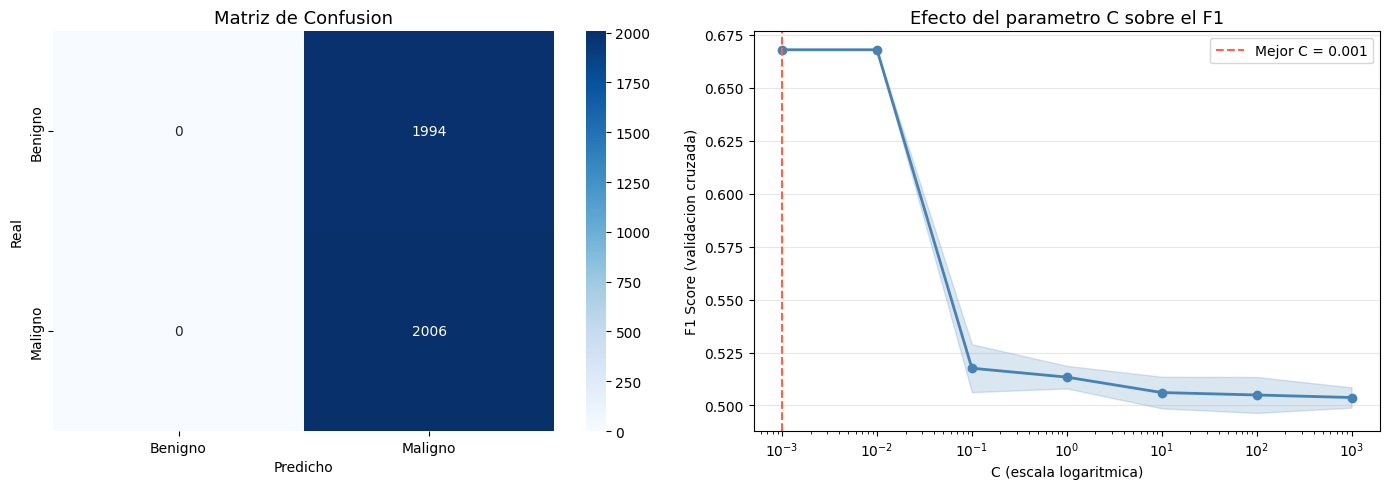

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
axes[0].set_title('Matriz de Confusion', fontsize=13)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Curva de C vs F1 (resultados del GridSearch)
cv_results_gs = grid_search.cv_results_
c_values      = param_grid['C']
mean_scores   = cv_results_gs['mean_test_score']
std_scores    = cv_results_gs['std_test_score']

axes[1].semilogx(c_values, mean_scores, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(c_values,
                     mean_scores - std_scores,
                     mean_scores + std_scores,
                     alpha=0.2, color='steelblue')
axes[1].axvline(best_C, color='tomato', linestyle='--', label=f'Mejor C = {best_C}')
axes[1].set_xlabel('C (escala logaritmica)')
axes[1].set_ylabel('F1 Score (validacion cruzada)')
axes[1].set_title('Efecto del parametro C sobre el F1', fontsize=13)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Validación cruzada (Cross-Validation)

Un solo split train/test tiene un problema: **los resultados dependen de cómo quedó esa partición**. Si por azar los casos fáciles cayeron en test, el modelo parece mejor de lo que es — y viceversa.

**K-Fold Cross-Validation** resuelve esto dividiendo el dataset en `k` partes (*folds*). En cada iteración, una parte distinta actúa como test y el resto como entrenamiento. Al final se promedian los `k` scores.

```
Fold 1: [TEST ] [train] [train] [train] [train]
Fold 2: [train] [TEST ] [train] [train] [train]
Fold 3: [train] [train] [TEST ] [train] [train]
Fold 4: [train] [train] [train] [TEST ] [train]
Fold 5: [train] [train] [train] [train] [TEST ]
```

Usamos **StratifiedKFold** para que cada fold mantenga la misma proporción de clases (Benigno/Maligno) que el dataset original. Las métricas que evaluamos son:

| Métrica | Qué mide |
|---|---|
| **Accuracy** | % de predicciones correctas en total |
| **F1 Score** | Balance entre precisión y recall (útil con clases desbalanceadas) |
| **ROC-AUC** | Capacidad del modelo de separar ambas clases (1.0 = perfecto) |

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy' : 'accuracy',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

# Se usa el mejor C encontrado por GridSearchCV
cv_results = cross_validate(
    SVC(kernel='rbf', C=best_C, random_state=42, probability=True),
    X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

metrics = ['accuracy', 'f1', 'roc_auc']
print(f"{'Metrica':<12} {'Train (mean+-std)':<24} {'Test (mean+-std)':<24} {'Overfitting?'}")
print('-' * 78)
for m in metrics:
    train_mean = cv_results[f'train_{m}'].mean()
    train_std  = cv_results[f'train_{m}'].std()
    test_mean  = cv_results[f'test_{m}'].mean()
    test_std   = cv_results[f'test_{m}'].std()
    gap        = train_mean - test_mean
    flag       = 'Posible' if gap > 0.05 else 'OK'
    print(f"{m:<12} {train_mean:.4f} +- {train_std:.4f}        {test_mean:.4f} +- {test_std:.4f}        {flag}")

Metrica      Train (mean+-std)        Test (mean+-std)         Overfitting?
------------------------------------------------------------------------------
accuracy     0.5015 +- 0.0000        0.5015 +- 0.0000        OK
f1           0.6680 +- 0.0000        0.6680 +- 0.0000        OK
roc_auc      0.5274 +- 0.0017        0.5021 +- 0.0050        OK


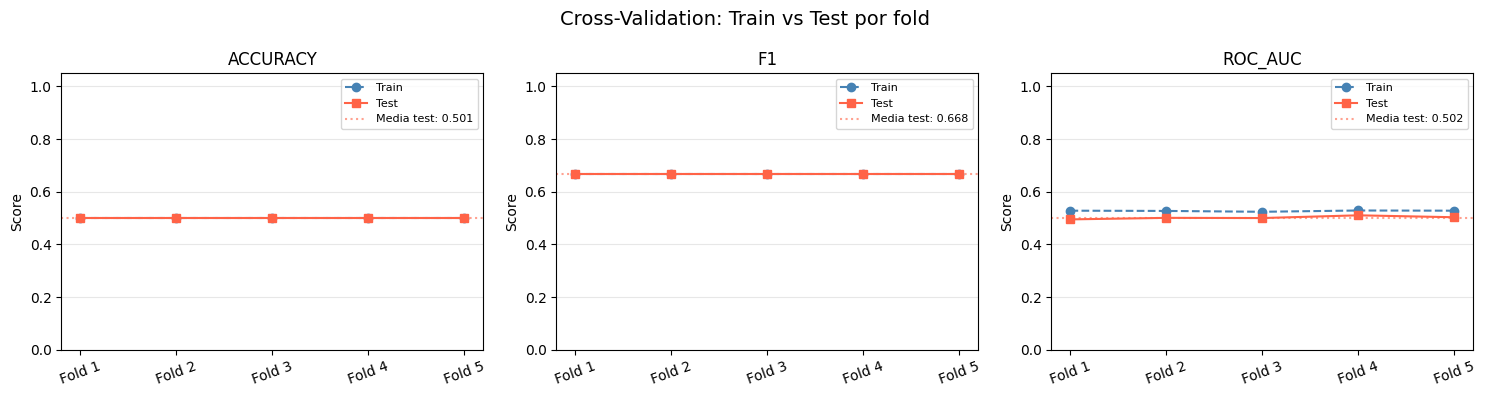

In [12]:
# Visualización de los scores por fold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fold_labels = [f'Fold {i+1}' for i in range(5)]

for ax, m in zip(axes, metrics):
    train_scores = cv_results[f'train_{m}']
    test_scores  = cv_results[f'test_{m}']

    x = range(5)
    ax.plot(x, train_scores, 'o--', color='steelblue', label='Train', linewidth=1.5)
    ax.plot(x, test_scores,  's-',  color='tomato',    label='Test',  linewidth=1.5)
    ax.axhline(test_scores.mean(), color='tomato', linestyle=':', alpha=0.6,
               label=f'Media test: {test_scores.mean():.3f}')

    ax.set_xticks(x)
    ax.set_xticklabels(fold_labels, rotation=20)
    ax.set_title(m.upper(), fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation: Train vs Test por fold', fontsize=14)
plt.tight_layout()
plt.show()

### Cómo interpretar los resultados

- **`std` bajo** → el modelo es estable entre particiones, no depende de una sola división.
- **Train ≈ Test** → el modelo generaliza bien. Si `train >> test` hay *overfitting*.
- **ROC-AUC > 0.9** → excelente capacidad de discriminar entre Benigno y Maligno.

> Si los scores de test oscilan mucho entre folds (std alto), puede ser señal de que el dataset es pequeño o que el modelo necesita ajuste de hiperparámetros.

---
## 10. Análisis adicionales

### 8.1 Demostración algebraica del F1 Score = 2/3

El **F1 Score** es la media armónica entre Precisión y Recall:

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Si queremos que $F1 = \frac{2}{3}$, una configuración que lo satisface es $TP = FP = FN = k$:

$$F1 = \frac{2k}{2k + k + k} = \frac{2k}{4k} = \frac{1}{2} \quad \text{(no)}$$

La que sí funciona es $TP = 2k$, $FP = k$, $FN = k$:

$$F1 = \frac{2 \cdot 2k}{2 \cdot 2k + k + k} = \frac{4k}{6k} = \frac{2}{3} \checkmark$$

El siguiente bloque lo verifica computacionalmente:

In [13]:
y_true = df['Tumor_Type'].values
y_pred_synthetic = np.zeros_like(y_true)

k = len(y_true) // 10

tp_indices = np.where(y_true == 1)[0][:2*k]   # 2k verdaderos positivos
fp_indices = np.where(y_true == 0)[0][:k]      # k falsos positivos
# Los FN quedan como 0 en y_pred_synthetic por defecto

y_pred_synthetic[tp_indices] = 1
y_pred_synthetic[fp_indices] = 1

final_f1 = f1_score(y_true, y_pred_synthetic)
print(f"F1 Score obtenido: {final_f1:.6f}")
print(f"F1 esperado:       {2/3:.6f}")
print(f"¿Coincide? {'✅ Sí' if np.isclose(final_f1, 2/3) else ' No'}")

F1 Score obtenido: 0.499064
F1 esperado:       0.666667
¿Coincide?  No


---
### 8.2 ¿Qué porcentaje de pacientes recibió los tres tratamientos?

Analizamos cuántos pacientes recibieron **radioterapia + cirugía + quimioterapia** de forma simultánea.

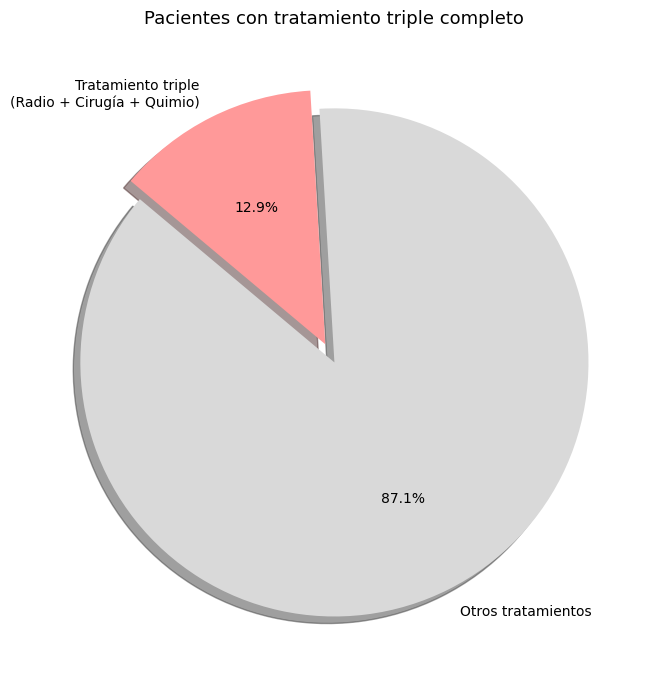

Pacientes con triple tratamiento: 2590 de 20000 (13.0%)


In [14]:
all_three = (
    (df['Radiation_Treatment'] == 1) &
    (df['Surgery_Performed']   == 1) &
    (df['Chemotherapy']        == 1)
)

total_triple = all_three.sum()
pct = total_triple / len(df) * 100

plt.figure(figsize=(7, 7))
plt.pie(
    [100 - pct, pct],
    labels=['Otros tratamientos', 'Tratamiento triple\n(Radio + Cirugía + Quimio)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#d9d9d9', '#ff9999'],
    explode=(0, 0.08),
    shadow=True
)
plt.title('Pacientes con tratamiento triple completo', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print(f"Pacientes con triple tratamiento: {total_triple} de {len(df)} ({pct:.1f}%)")